<a href="https://colab.research.google.com/github/11icy/ML/blob/notebooks/machine_learning_classique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

In [ ]:
base_url = "https://raw.githubusercontent.com/11icy/ML/main/data/processed/"

X_train = pd.read_csv(base_url + "X_train.csv")
X_test  = pd.read_csv(base_url + "X_test.csv")

y_train = pd.read_csv(base_url + "y_train.csv").squeeze()
y_test  = pd.read_csv(base_url + "y_test.csv").squeeze()

In [ ]:
X_train = X_train.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])
X_test  = X_test.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

In [ ]:
X_train = pd.get_dummies(X_train, columns=["Type"], drop_first=True)
X_test  = pd.get_dummies(X_test, columns=["Type"], drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("AUC-ROC :", roc_auc_score(y_test, y_prob))

Recall : 0.8235294117647058
F1-score : 0.25301204819277107
AUC-ROC : 0.8966427150570373


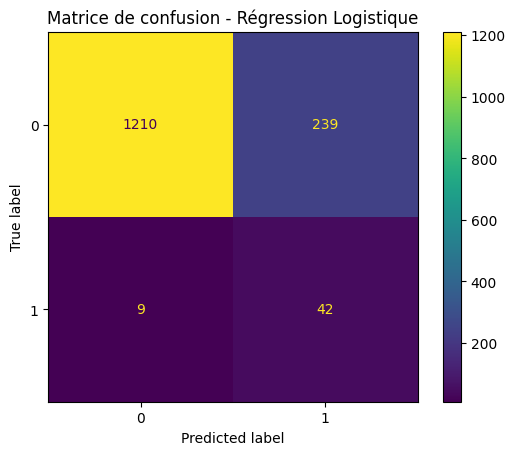

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matrice de confusion - Régression Logistique")
plt.show()

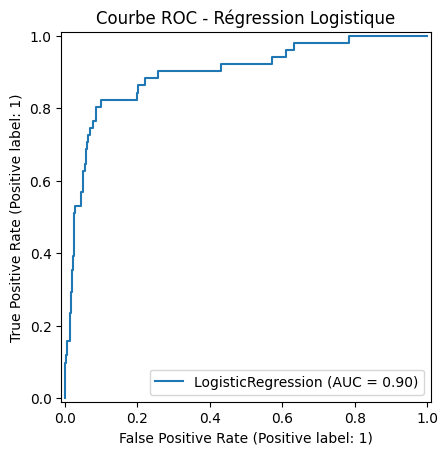

In [ ]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.title("Courbe ROC - Régression Logistique")
plt.show()